# lapse_rate 模块算法验证

本 Notebook 分两步验证：

- **数据预处理**：将官方投影坐标样例映射为当前实现可读的 `lat/lon` 六维输入。
- **结果对比**：读取原方法结果、修改后算法结果和 KGO，做数值统计与可视化对比。

验证划分为两套方案：

1. **方案一（投影坐标 / 维名重命名）**：预处理仅重命名投影维；写出 `cli_input/` 供 CLI；结果写入 `cli_output/`；KGO 与原方法结果直接读官方投影 nc。
2. **方案二（经纬坐标 / 重网格）**：预处理阶段进行投影转经纬以及重网格处理；修改后算法与原方法均使用转换后数据。

## 环境准备

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from orographic_temperature_downscaling.src.lapse_rate import ApplyGriddedLapseRate, DALR, ELR, LapseRate

print(f"干绝热递减率 (DALR): {DALR} K/m")
print(f"环境递减率 (ELR): {ELR} K/m")


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


干绝热递减率 (DALR): -0.0098 K/m
环境递减率 (ELR): -0.0065 K/m


## 方案一：投影坐标输入

### 1. 数据预处理

In [2]:
import json

from orographic_temperature_downscaling.utils.utils import rebuild_to_meb_griddata

APPLY_DATA_DIR = (PACKAGE_ROOT / "test_data/apply_lapse_rate_data").resolve()
LAPSE_DATA_DIR = (PACKAGE_ROOT / "test_data/temp_lapse_rate_data").resolve()
APPLY_CLI_INPUT_DIR = APPLY_DATA_DIR / "cli_input"
APPLY_CLI_OUTPUT_DIR = APPLY_DATA_DIR / "cli_output"
LAPSE_CLI_INPUT_DIR = LAPSE_DATA_DIR / "cli_input"
LAPSE_CLI_OUTPUT_DIR = LAPSE_DATA_DIR / "cli_output"


def load_primary_dataarray(nc_path: Path, var_name: str) -> xr.DataArray:
    """读取 netCDF 主变量，并写入 grid_mapping_attrs。"""
    ds = xr.open_dataset(nc_path, decode_timedelta=False)
    try:
        if var_name not in ds.data_vars:
            raise ValueError(f"变量 {var_name} 不存在: {nc_path}")
        data = ds[var_name].load()
        
        # 将投影定义序列化到主变量 attrs，供 CLI 读取六维 nc 时直接解析。
        grid_mapping_name = data.attrs.get("grid_mapping")
        if isinstance(grid_mapping_name, str) and grid_mapping_name in ds.variables:
            mapping_attrs_raw = dict(ds[grid_mapping_name].attrs)
            mapping_attrs_json_ready = {}
            for key, value in mapping_attrs_raw.items():
                if isinstance(value, np.ndarray):
                    mapping_attrs_json_ready[key] = value.tolist()
                elif isinstance(value, np.generic):
                    mapping_attrs_json_ready[key] = value.item()
                else:
                    mapping_attrs_json_ready[key] = value
            data.attrs["grid_mapping_attrs"] = json.dumps(
                mapping_attrs_json_ready, ensure_ascii=False
            )
        return data
    finally:
        ds.close()


def _extract_projected_spatial_2d(da: xr.DataArray) -> xr.DataArray:
    """提取二维空间场，并将投影维名统一映射为 lat/lon。"""
    arr = da
    # 除空间维外，其余维度都取第一个切片
    for dim in list(arr.dims):
        if dim not in ("projection_y_coordinate", "projection_x_coordinate", "lat", "lon"):
            arr = arr.isel({dim: 0}, drop=True)
    # 将投影坐标维名映射成当前实现可识别的 lat/lon
    rename_map = {}
    if "projection_y_coordinate" in arr.dims:
        rename_map["projection_y_coordinate"] = "lat"
    if "projection_x_coordinate" in arr.dims:
        rename_map["projection_x_coordinate"] = "lon"
    if rename_map:
        arr = arr.rename(rename_map)
    # 强制维度顺序统一，避免后续拼装不一致
    if arr.dims != ("lat", "lon"):
        arr = arr.transpose("lat", "lon")
    return arr


def _build_meb6d_from_spatial_2d(
    spatial: xr.DataArray,
    *,
    name: str,
    extra_attrs: dict | None = None,
) -> xr.DataArray:
    """由二维 lat/lon 场构造六维 meb 网格。"""
    units = str(spatial.attrs.get("units", "1"))
    values = spatial.values[np.newaxis, np.newaxis, np.newaxis, np.newaxis, :, :].astype(np.float32)
    
    # 构造默认属性
    attrs = {
        "units": units,
        "model": None,
        "dtime_units": "hour",
        "level_type": "isobaric",
        "time_type": "UT",
        "time_bounds": [0, 0],
    }
    if extra_attrs:
        attrs.update(extra_attrs)
    
    grid_mapping_attrs = spatial.attrs.get("grid_mapping_attrs")
    if isinstance(grid_mapping_attrs, str) and grid_mapping_attrs.strip():
        attrs["grid_mapping_attrs"] = grid_mapping_attrs
    
    # 直接构造六维 DataArray，不经过 rebuild_to_meb_griddata
    result = xr.DataArray(
        values,
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": np.array(["data0"], dtype=object),
            "level": np.array([0.0], dtype=np.float32),
            "time": np.array([np.datetime64("1970-01-01T00:00:00")], dtype="datetime64[ns]"),
            "dtime": np.array([0], dtype=np.int32),
            "lat": spatial.coords["lat"].copy(deep=True),
            "lon": spatial.coords["lon"].copy(deep=True),
        },
        attrs=attrs,
        name=name,
    )
    return result

def build_meb6d_from_projected(nc_path: Path, var_name: str) -> xr.DataArray:
    """由投影样例构造六维输入（仅维名重命名）。"""
    spatial = _extract_projected_spatial_2d(load_primary_dataarray(nc_path, var_name))
    return _build_meb6d_from_spatial_2d(
        spatial,
        name=var_name,
    )


def save_meb6d_to_nc(data: xr.DataArray, dst_path: Path) -> None:
    """将内存中的六维 meb 数据写出为 nc（供 CLI 读取）。"""
    normalized = data.copy(deep=True)
    normalized.attrs = {k: ("" if v is None else v) for k, v in dict(normalized.attrs).items()}
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    normalized.to_dataset(name=normalized.name).to_netcdf(dst_path)


def to_2d_values(data: xr.DataArray) -> np.ndarray:
    """将 DataArray 统一提取为二维 numpy 数组（lat, lon）。"""
    arr = data
    if {"projection_y_coordinate", "projection_x_coordinate"}.issubset(set(arr.dims)):
        arr = _extract_projected_spatial_2d(arr)
    else:
        for dim in list(arr.dims):
            if dim not in ("lat", "lon"):
                arr = arr.isel({dim: 0}, drop=True)
        if arr.dims != ("lat", "lon"):
            arr = arr.transpose("lat", "lon")
    return np.asarray(arr.values, dtype=np.float64)


def compare_stats(current: xr.DataArray, reference: xr.DataArray, tag: str):
    """对比两个二维场，计算平均绝对误差、最大绝对误差和均方根误差。"""
    c = to_2d_values(current)
    r = to_2d_values(reference)
    if c.shape != r.shape:
        raise ValueError(f"二维场形状不一致: current={c.shape}, reference={r.shape}")
    diff = c - r
    print(f"[{tag}] mean_abs={np.mean(np.abs(diff)):.8f}, max_abs={np.max(np.abs(diff)):.8f}, rmse={np.sqrt(np.mean(diff**2)):.8f}")
    return c, r, diff


def plot_compare_triplet(modified, kgo, original, *, title: str, cmap: str, unit: str, vmin=None, vmax=None):
    """绘制结果图"""
    m = to_2d_values(modified) if isinstance(modified, xr.DataArray) else np.asarray(modified)
    k = to_2d_values(kgo) if isinstance(kgo, xr.DataArray) else np.asarray(kgo)
    o = to_2d_values(original) if isinstance(original, xr.DataArray) else np.asarray(original)
    if vmin is None:
        vmin = min(m.min(), k.min(), o.min())
    if vmax is None:
        vmax = max(m.max(), k.max(), o.max())
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=16)
    for ax, arr, label in zip(axes, [m, k, o], ["修改后算法", "KGO", "原算法"]):
        im = ax.imshow(arr, cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(label)
        plt.colorbar(im, ax=ax, fraction=0.046, label=unit)
    plt.tight_layout()
    plt.show()


In [3]:
# 方案一：读原数据 → 预处理 → 写出 cli_input（供 CLI）；算法验证使用内存数据
apply_scheme1_jobs = [
    ("ukvx_temperature.nc", "air_temperature"),
    ("ukvx_lapse_rate.nc", "lapse_rate"),
    ("ukvx_orography.nc", "surface_altitude"),
    ("highres_orog.nc", "surface_altitude"),
]
lapse_scheme1_jobs = [
    ("temperature_at_screen_level.nc", "air_temperature"),
    ("ukvx_orography.nc", "surface_altitude"),
    ("ukvx_landmask.nc", "land_binary_mask"),
]

# ApplyGriddedLapseRate 输入
apply_temperature_meb = build_meb6d_from_projected(
    APPLY_DATA_DIR / "ukvx_temperature.nc", var_name="air_temperature"
)
apply_lapse_rate_meb = build_meb6d_from_projected(
    APPLY_DATA_DIR / "ukvx_lapse_rate.nc", var_name="lapse_rate"
)
apply_source_orog_meb = build_meb6d_from_projected(
    APPLY_DATA_DIR / "ukvx_orography.nc", var_name="surface_altitude"
)
apply_dest_orog_meb = build_meb6d_from_projected(
    APPLY_DATA_DIR / "highres_orog.nc", var_name="surface_altitude"
)

# LapseRate 输入
lapse_temperature_meb = build_meb6d_from_projected(
    LAPSE_DATA_DIR / "temperature_at_screen_level.nc", var_name="air_temperature"
)
lapse_orog_meb = build_meb6d_from_projected(
    LAPSE_DATA_DIR / "ukvx_orography.nc", var_name="surface_altitude"
)
lapse_mask_meb = build_meb6d_from_projected(
    LAPSE_DATA_DIR / "ukvx_landmask.nc", var_name="land_binary_mask"
)

# 写出 cli_input（供 CLI / pytest 读取）
apply_scheme1_outputs = [
    ("ukvx_temperature.nc", apply_temperature_meb),
    ("ukvx_lapse_rate.nc", apply_lapse_rate_meb),
    ("ukvx_orography.nc", apply_source_orog_meb),
    ("highres_orog.nc", apply_dest_orog_meb),
]
lapse_scheme1_outputs = [
    ("temperature_at_screen_level.nc", lapse_temperature_meb),
    ("ukvx_orography.nc", lapse_orog_meb),
    ("ukvx_landmask.nc", lapse_mask_meb),
]

for filename, data in apply_scheme1_outputs:
    save_meb6d_to_nc(data, APPLY_CLI_INPUT_DIR / filename)
    print(f"写出: {APPLY_CLI_INPUT_DIR / filename}")
for filename, data in lapse_scheme1_outputs:
    save_meb6d_to_nc(data, LAPSE_CLI_INPUT_DIR / filename)
    print(f"写出: {LAPSE_CLI_INPUT_DIR / filename}")

print("方案一 Apply 输入:", apply_temperature_meb.dims, apply_temperature_meb.shape)
print("方案一 Lapse 输入:", lapse_temperature_meb.dims, lapse_temperature_meb.shape)

写出: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\cli_input\ukvx_temperature.nc
写出: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\cli_input\ukvx_lapse_rate.nc
写出: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\cli_input\ukvx_orography.nc
写出: D:\workspace\improver\temperature\test_data\apply_lapse_rate_data\cli_input\highres_orog.nc
写出: D:\workspace\improver\temperature\test_data\temp_lapse_rate_data\cli_input\temperature_at_screen_level.nc
写出: D:\workspace\improver\temperature\test_data\temp_lapse_rate_data\cli_input\ukvx_orography.nc
写出: D:\workspace\improver\temperature\test_data\temp_lapse_rate_data\cli_input\ukvx_landmask.nc
方案一 Apply 输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 100, 100)
方案一 Lapse 输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 120, 110)


In [4]:
apply_temperature_meb

<xarray.DataArray 'air_temperature' (member: 1, level: 1, time: 1, dtime: 1,
                                     lat: 100, lon: 100)> Size: 40kB
array([[[[[[286.9542 , 286.92758, 286.89575, ..., 289.3587 ,
            289.37286, 289.37894],
           [286.94815, 286.9069 , 286.875  , ..., 289.64197,
            289.6126 , 289.57333],
           [286.92783, 286.88937, 286.8653 , ..., 289.46255,
            289.6153 , 289.81912],
           ...,
           [287.25034, 286.86206, 287.17783, ..., 287.26767,
            287.4298 , 287.48718],
           [287.3102 , 287.12085, 287.27722, ..., 287.2179 ,
            287.2345 , 287.38593],
           [287.07632, 287.3504 , 287.29144, ..., 286.21893,
            287.15488, 287.2539 ]]]]]],
      shape=(1, 1, 1, 1, 100, 100), dtype=float32)
Coordinates:
  * member   (member) object 8B 'data0'
  * level    (level) float32 4B 0.0
  * time     (time) datetime64[ns] 8B 1970-01-01
  * dtime    (dtime) int32 4B 0
  * lat      (lat) float32 400B 1.64e+05 1.66e+05 1.68e+05 ... 3.6e+05 3.62e+05
  * lon      (lon) float32 400B -2.58e+05 -2.56e+05 ... -6.2e+04 -6e+04
Attributes:
    units:               K
    model:               None
    dtime_units:         hour
    level_type:          isobaric
    time_type:           UT
    time_bounds:         [0, 0]
    grid_mapping_attrs:  {"grid_mapping_name": "lambert_azimuthal_equal_area"...

### 2. ApplyGriddedLapseRate

=== 方案一：ApplyGriddedLapseRate ===
[方案一 修改后-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000
[方案一 修改后-原算法] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000
[方案一 原算法-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000


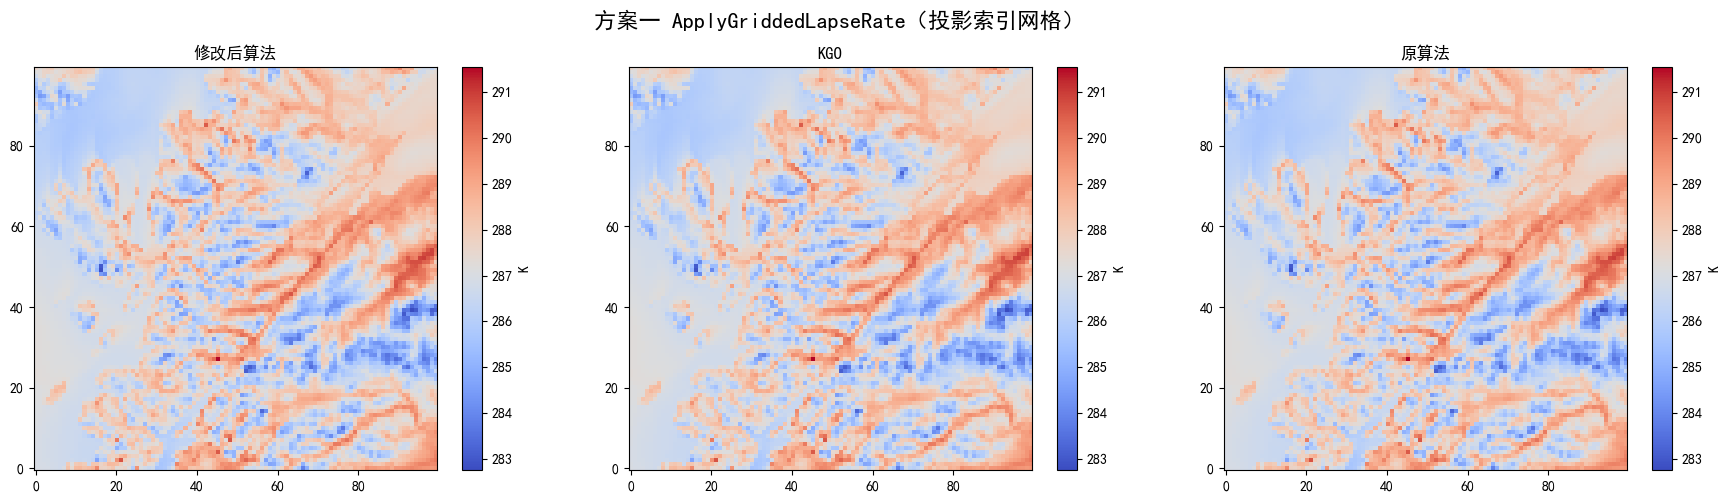

In [5]:
print("=== 方案一：ApplyGriddedLapseRate ===")
apply_modified_s1 = ApplyGriddedLapseRate()(
    apply_temperature_meb, apply_lapse_rate_meb, apply_source_orog_meb, apply_dest_orog_meb,
)
apply_kgo_s1 = load_primary_dataarray(APPLY_DATA_DIR / "kgo.nc", "air_temperature")
apply_original_s1 = load_primary_dataarray(APPLY_DATA_DIR / "original_algorithm_result.nc", "air_temperature")

compare_stats(apply_modified_s1, apply_kgo_s1, "方案一 修改后-KGO")
compare_stats(apply_modified_s1, apply_original_s1, "方案一 修改后-原算法")
compare_stats(apply_original_s1, apply_kgo_s1, "方案一 原算法-KGO")
plot_compare_triplet(
    apply_modified_s1, apply_kgo_s1, apply_original_s1,
    title="方案一 ApplyGriddedLapseRate（投影索引网格）", cmap="coolwarm", unit="K",
)


### 3. LapseRate

=== 方案一：LapseRate ===
[方案一 修改后-KGO] mean_abs=0.00000000, max_abs=0.00000001, rmse=0.00000000
[方案一 修改后-原算法] mean_abs=0.00000000, max_abs=0.00000001, rmse=0.00000000
[方案一 原算法-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000


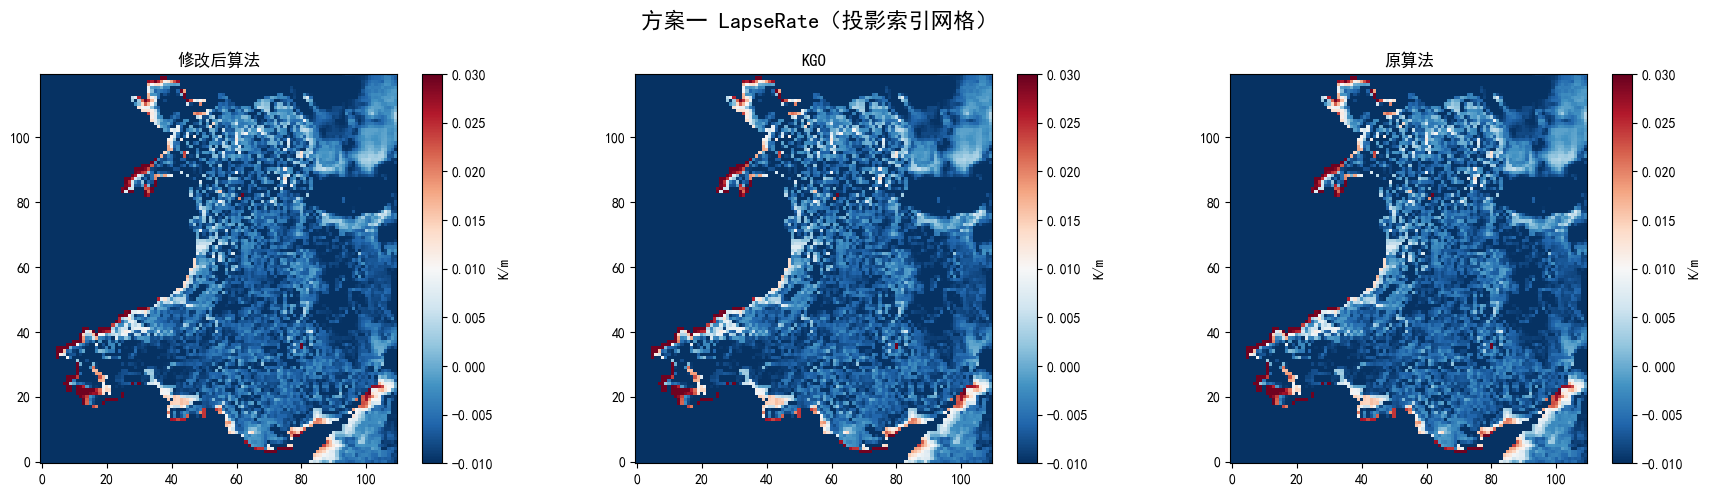

In [6]:
print("=== 方案一：LapseRate ===")
lapse_modified_s1 = LapseRate()(lapse_temperature_meb, lapse_orog_meb, lapse_mask_meb)
lapse_kgo_s1 = load_primary_dataarray(LAPSE_DATA_DIR / "kgo.nc", "air_temperature_lapse_rate")
lapse_original_s1 = load_primary_dataarray(LAPSE_DATA_DIR / "original_lapse_rate_result.nc", "air_temperature_lapse_rate")

compare_stats(lapse_modified_s1, lapse_kgo_s1, "方案一 修改后-KGO")
compare_stats(lapse_modified_s1, lapse_original_s1, "方案一 修改后-原算法")
compare_stats(lapse_original_s1, lapse_kgo_s1, "方案一 原算法-KGO")
plot_compare_triplet(
    lapse_modified_s1, lapse_kgo_s1, lapse_original_s1,
    title="方案一 LapseRate（投影索引网格）", cmap="RdBu_r", unit="K/m", vmin=-0.01, vmax=0.03,
)


## 方案二：经纬坐标输入

### 1. 数据预处理

在内存中将输入与 KGO 重网格到规则经纬网格（**不写 nc**）。

In [7]:
from pyproj import CRS, Transformer
from scipy.interpolate import griddata

import iris
from iris.coord_systems import GeogCS
from iris.coords import DimCoord
from iris.cube import Cube

if str(PROJECT_ROOT / "improver-1.18.7") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "improver-1.18.7"))

from improver.temperature.lapse_rate import (
    ApplyGriddedLapseRate as OrigApplyGriddedLapseRate,
    LapseRate as OrigLapseRate,
)


def _regularize_axis(values: np.ndarray) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float64).reshape(-1)
    if arr.size < 2:
        return arr
    step = np.nanmedian(np.diff(arr))
    if not np.isfinite(step) or np.isclose(step, 0.0):
        return arr
    return arr[0] + step * np.arange(arr.size, dtype=np.float64)


def projected_da_to_regular_latlon_2d(data: xr.DataArray, *, method: str = "linear") -> xr.DataArray:
    arr = data
    for dim in list(arr.dims):
        if dim not in ("projection_y_coordinate", "projection_x_coordinate", "lat", "lon"):
            arr = arr.isel({dim: 0}, drop=True)
    if not {"projection_y_coordinate", "projection_x_coordinate"}.issubset(set(arr.dims)):
        return _extract_projected_spatial_2d(arr)
    mapping_json = arr.attrs.get("grid_mapping_attrs")
    if not isinstance(mapping_json, str) or not mapping_json.strip():
        raise ValueError("缺少 grid_mapping_attrs，无法做投影转经纬重网格。")
    mapping_attrs = json.loads(mapping_json)
    y = np.asarray(arr.coords["projection_y_coordinate"].values, dtype=np.float64)
    x = np.asarray(arr.coords["projection_x_coordinate"].values, dtype=np.float64)
    yy, xx = np.meshgrid(y, x, indexing="ij")
    transformer = Transformer.from_crs(CRS.from_cf(mapping_attrs), CRS.from_epsg(4326), always_xy=True)
    lon2d_src, lat2d_src = transformer.transform(xx, yy)
    lat_1d = _regularize_axis(np.nanmean(lat2d_src, axis=1))
    lon_1d = _regularize_axis(np.nanmean(lon2d_src, axis=0))
    lat2d_tgt, lon2d_tgt = np.meshgrid(lat_1d, lon_1d, indexing="ij")
    src_points = np.column_stack([lat2d_src.ravel(), lon2d_src.ravel()])
    src_values = np.asarray(arr.values, dtype=np.float64).ravel()
    tgt_points = np.column_stack([lat2d_tgt.ravel(), lon2d_tgt.ravel()])
    interp_values = griddata(src_points, src_values, tgt_points, method=method)
    nan_mask = np.isnan(interp_values)
    if np.any(nan_mask):
        interp_nn = griddata(src_points, src_values, tgt_points, method="nearest")
        interp_values[nan_mask] = interp_nn[nan_mask]
    return xr.DataArray(
        interp_values.reshape(lat2d_tgt.shape).astype(np.float64),
        dims=("lat", "lon"),
        coords={"lat": lat_1d, "lon": lon_1d},
        name=str(arr.name or "field"),
        attrs={"units": str(arr.attrs.get("units", "1"))},
    )


def build_meb6d_from_latlon(nc_path: Path, var_name: str) -> xr.DataArray:
    """由投影样例构造六维输入（仅维名重命名）。"""
    spatial = projected_da_to_regular_latlon_2d(load_primary_dataarray(nc_path, var_name))
    return _build_meb6d_from_spatial_2d(
        spatial,
        name=var_name,
        extra_attrs={
            "grid_mapping_attrs": json.dumps(
                {"grid_mapping_name": "latitude_longitude"},
                ensure_ascii=False,
            ),
        },
    )


def meb6d_to_iris_2d(da: xr.DataArray, *, name: str, units: str) -> Cube:
    arr2d = da.squeeze(drop=True).transpose("lat", "lon")
    cs = GeogCS(6378137.0)
    lat = DimCoord(np.asarray(arr2d.coords["lat"].values, dtype=np.float64), standard_name="latitude", units="degrees", coord_system=cs)
    lon = DimCoord(np.asarray(arr2d.coords["lon"].values, dtype=np.float64), standard_name="longitude", units="degrees", coord_system=cs)
    return Cube(
        np.asarray(arr2d.values, dtype=np.float32),
        long_name=name,
        units=units,
        dim_coords_and_dims=[(lat, 0), (lon, 1)],
    )


def iris_cube_to_xr2d(cube: Cube, *, name: str) -> xr.DataArray:
    return xr.DataArray(
        np.asarray(cube.data, dtype=np.float64),
        dims=("lat", "lon"),
        coords={
            "lat": np.asarray(cube.coord(axis="y").points, dtype=np.float64),
            "lon": np.asarray(cube.coord(axis="x").points, dtype=np.float64),
        },
        name=name,
    )


In [8]:
# 方案二：内存预处理（不写盘）
apply_temperature_latlon = build_meb6d_from_latlon(APPLY_DATA_DIR / "ukvx_temperature.nc", "air_temperature")
apply_lapse_rate_latlon = build_meb6d_from_latlon(APPLY_DATA_DIR / "ukvx_lapse_rate.nc", "lapse_rate")
apply_source_orog_latlon = build_meb6d_from_latlon(APPLY_DATA_DIR / "ukvx_orography.nc", "surface_altitude")
apply_dest_orog_latlon = build_meb6d_from_latlon(APPLY_DATA_DIR / "highres_orog.nc", "surface_altitude")
apply_kgo_latlon = build_meb6d_from_latlon(APPLY_DATA_DIR / "kgo.nc", "air_temperature")


lapse_temperature_latlon = build_meb6d_from_latlon(LAPSE_DATA_DIR / "temperature_at_screen_level.nc", "air_temperature")
lapse_orog_latlon = build_meb6d_from_latlon(LAPSE_DATA_DIR / "ukvx_orography.nc", "surface_altitude")
lapse_mask_latlon = build_meb6d_from_latlon(LAPSE_DATA_DIR / "ukvx_landmask.nc", "land_binary_mask")
lapse_kgo_latlon = build_meb6d_from_latlon(LAPSE_DATA_DIR / "kgo.nc", "air_temperature_lapse_rate")

print("方案二 Apply 输入:", apply_temperature_latlon.dims, apply_temperature_latlon.shape)
print("方案二 Lapse 输入:", lapse_temperature_latlon.dims, lapse_temperature_latlon.shape)


方案二 Apply 输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 100, 100)
方案二 Lapse 输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 120, 110)


### 2. ApplyGriddedLapseRate

=== 方案二：ApplyGriddedLapseRate ===
[方案二 修改后-KGO] mean_abs=0.03942319, max_abs=2.00601196, rmse=0.10490051
[方案二 修改后-原算法] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000
[方案二 原算法-KGO] mean_abs=0.03942319, max_abs=2.00601196, rmse=0.10490051


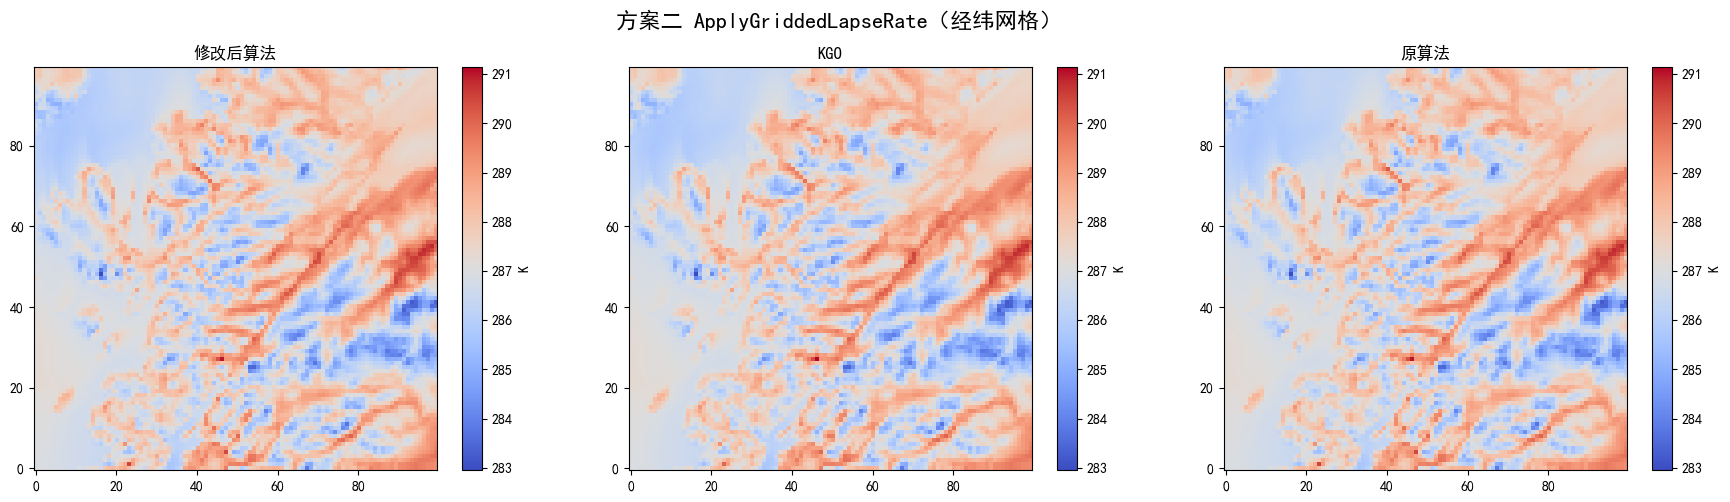

In [9]:
print("=== 方案二：ApplyGriddedLapseRate ===")
apply_modified_s2 = ApplyGriddedLapseRate()(
    apply_temperature_latlon, apply_lapse_rate_latlon, apply_source_orog_latlon, apply_dest_orog_latlon,
)
orig_apply_cube = OrigApplyGriddedLapseRate().process(
    meb6d_to_iris_2d(apply_temperature_latlon, name="air_temperature", units="K"),
    meb6d_to_iris_2d(apply_lapse_rate_latlon, name="lapse_rate", units="K m-1"),
    meb6d_to_iris_2d(apply_source_orog_latlon, name="surface_altitude", units="m"),
    meb6d_to_iris_2d(apply_dest_orog_latlon, name="surface_altitude", units="m"),
)
apply_original_s2 = iris_cube_to_xr2d(orig_apply_cube, name="air_temperature")

compare_stats(apply_modified_s2, apply_kgo_latlon, "方案二 修改后-KGO")
compare_stats(apply_modified_s2, apply_original_s2, "方案二 修改后-原算法")
compare_stats(apply_original_s2, apply_kgo_latlon, "方案二 原算法-KGO")
plot_compare_triplet(
    apply_modified_s2, apply_kgo_latlon, apply_original_s2,
    title="方案二 ApplyGriddedLapseRate（经纬网格）", cmap="coolwarm", unit="K",
)

### 3. LapseRate

=== 方案二：LapseRate ===
[方案二 修改后-KGO] mean_abs=0.00175859, max_abs=0.03920000, rmse=0.00430313
[方案二 修改后-原算法] mean_abs=0.00000000, max_abs=0.00000001, rmse=0.00000000
[方案二 原算法-KGO] mean_abs=0.00175859, max_abs=0.03920000, rmse=0.00430313


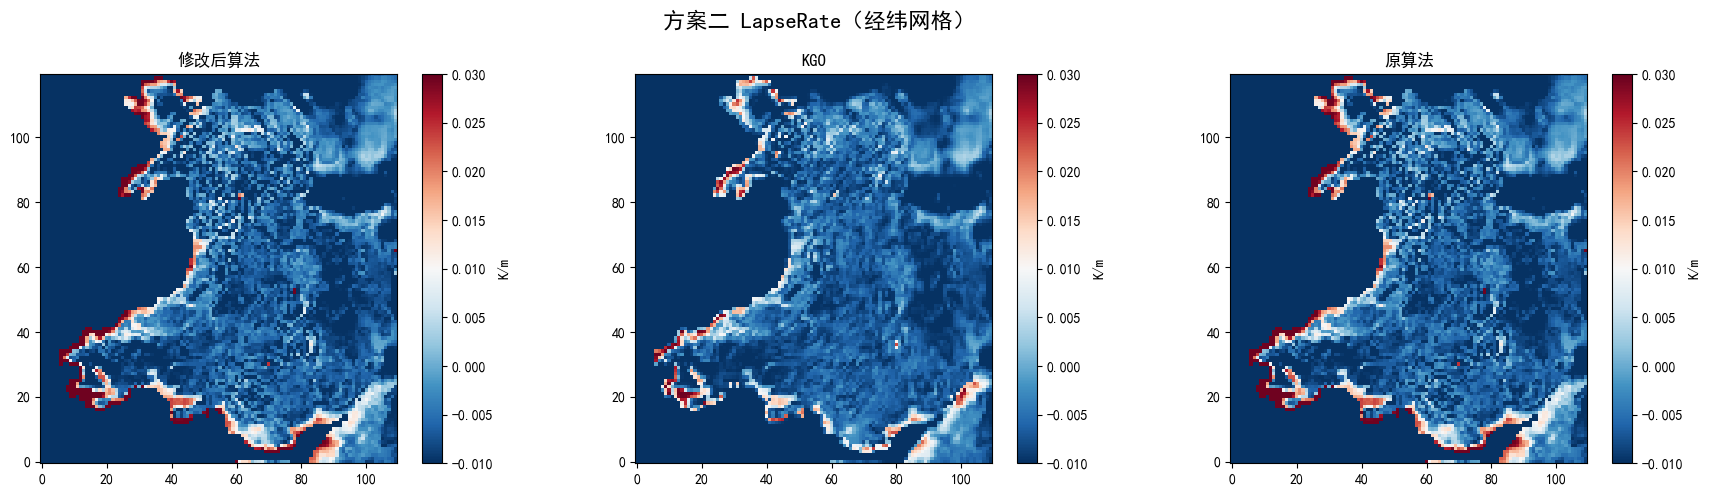

In [10]:
print("=== 方案二：LapseRate ===")
lapse_modified_s2 = LapseRate()(lapse_temperature_latlon, lapse_orog_latlon, lapse_mask_latlon)
orig_lapse_cube = OrigLapseRate().process(
    meb6d_to_iris_2d(lapse_temperature_latlon, name="air_temperature", units="K"),
    meb6d_to_iris_2d(lapse_orog_latlon, name="surface_altitude", units="m"),
    meb6d_to_iris_2d(lapse_mask_latlon, name="land_binary_mask", units="1"),
)
lapse_original_s2 = iris_cube_to_xr2d(orig_lapse_cube, name="air_temperature_lapse_rate")

compare_stats(lapse_modified_s2, lapse_kgo_latlon, "方案二 修改后-KGO")
compare_stats(lapse_modified_s2, lapse_original_s2, "方案二 修改后-原算法")
compare_stats(lapse_original_s2, lapse_kgo_latlon, "方案二 原算法-KGO")
plot_compare_triplet(
    lapse_modified_s2, lapse_kgo_latlon, lapse_original_s2,
    title="方案二 LapseRate（经纬网格）", cmap="RdBu_r", unit="K/m", vmin=-0.01, vmax=0.03,
)


## CLI 应用示例与结果对比

CLI 从方案一写出目录 `cli_input/` 读取输入，结果写入 `cli_output/`。

终端示例：`python -m orographic_temperature_downscaling.cli.anc_lapse_rate` / `python -m orographic_temperature_downscaling.cli.dsc_temp_lapse_rate`

### 1. ApplyGriddedLapseRate

[修改后算法CLI-原算法CLI] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000
[修改后算法CLI-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000
[原算法CLI-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000


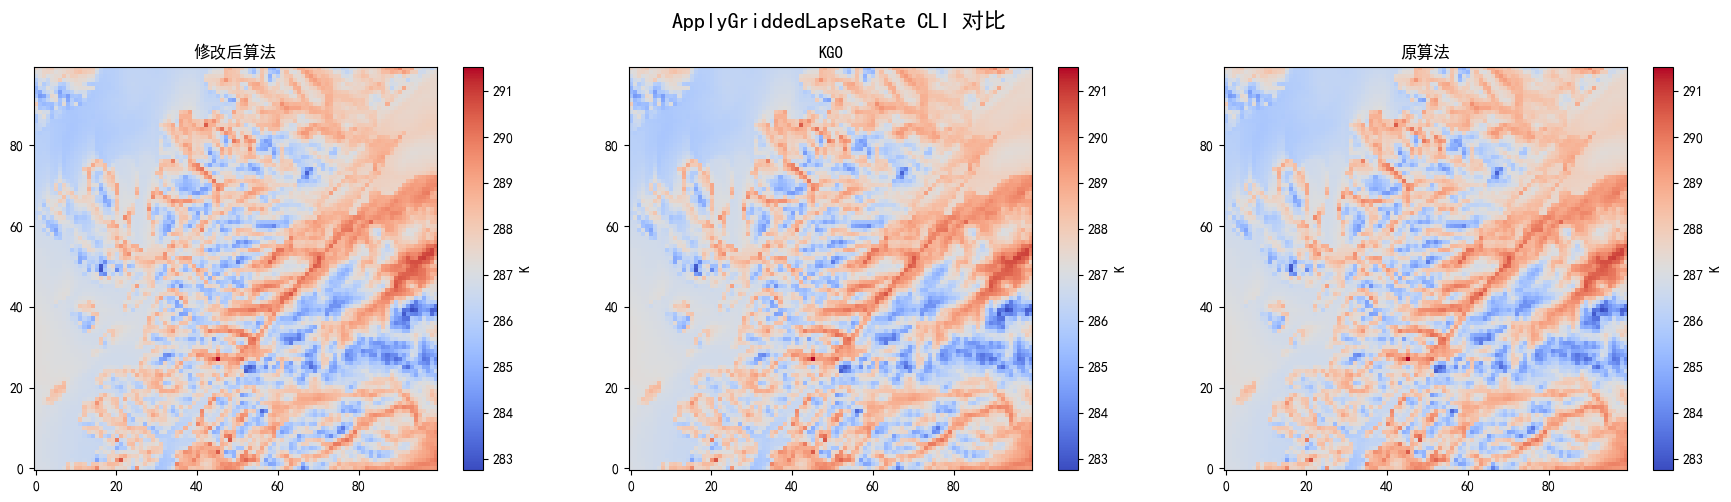

In [11]:
from orographic_temperature_downscaling.cli.anc_lapse_rate import process as cli_apply_process

original_cli_apply_path = APPLY_DATA_DIR / "original_cli_result.nc"

# 修改后算法 CLI 结果
cli_apply_result = cli_apply_process(
    str(APPLY_CLI_INPUT_DIR / "ukvx_temperature.nc"),
    str(APPLY_CLI_INPUT_DIR / "ukvx_lapse_rate.nc"),
    str(APPLY_CLI_INPUT_DIR / "ukvx_orography.nc"),
    str(APPLY_CLI_INPUT_DIR / "highres_orog.nc"),
    output_path=None,
)

# 原算法 CLI 与 KGO
orig_cli_apply = load_primary_dataarray(original_cli_apply_path, "air_temperature")

compare_stats(cli_apply_result, orig_cli_apply, "修改后算法CLI-原算法CLI")
compare_stats(cli_apply_result, apply_kgo_s1, "修改后算法CLI-KGO")
compare_stats(orig_cli_apply, apply_kgo_s1, "原算法CLI-KGO")
plot_compare_triplet(
    cli_apply_result, apply_kgo_s1, orig_cli_apply,
    title="ApplyGriddedLapseRate CLI 对比", cmap="coolwarm", unit="K",
)


### 2. LapseRate

[修改后算法CLI-KGO] mean_abs=0.00000000, max_abs=0.00000001, rmse=0.00000000
[修改后算法CLI-原算法CLI] mean_abs=0.00000000, max_abs=0.00000001, rmse=0.00000000
[原算法CLI-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000


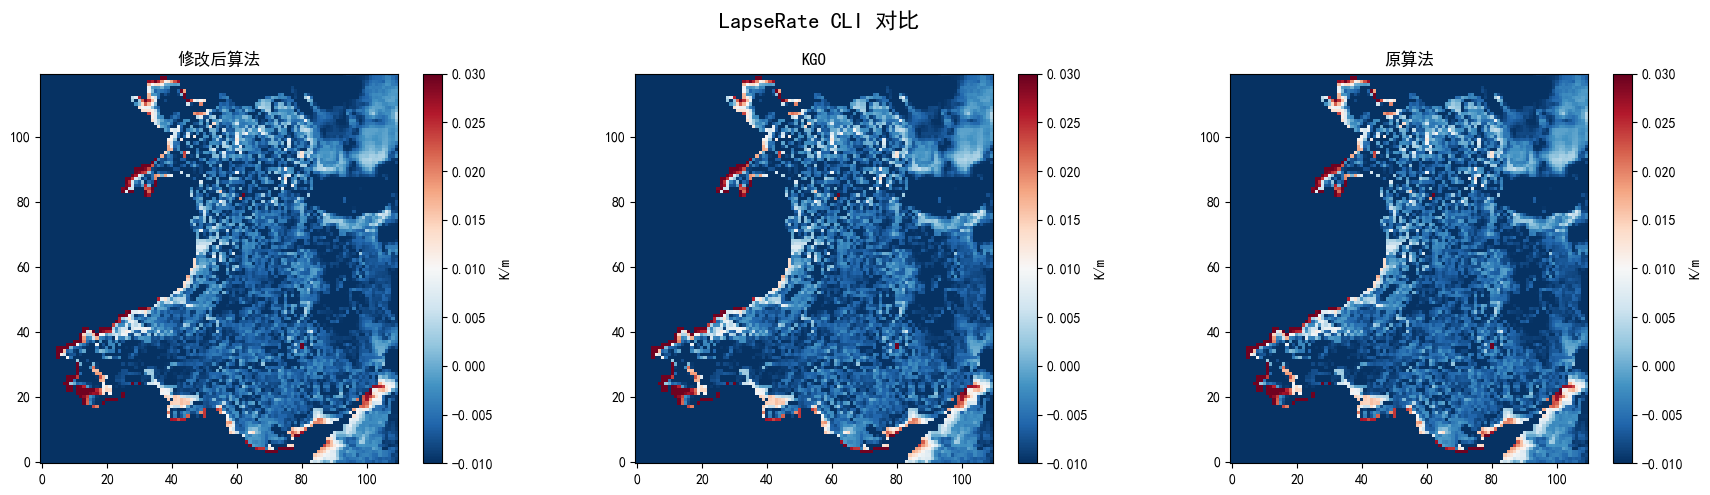

In [12]:
from orographic_temperature_downscaling.cli.dsc_temp_lapse_rate import process

cli_lapse_result = process(
    str(LAPSE_CLI_INPUT_DIR / "temperature_at_screen_level.nc"),
    str(LAPSE_CLI_INPUT_DIR / "ukvx_orography.nc"),
    str(LAPSE_CLI_INPUT_DIR / "ukvx_landmask.nc"),
    output_path=None,
)
orig_cli_lapse_path = LAPSE_DATA_DIR / "original_cli_result.nc"

orig_cli_lapse_result = load_primary_dataarray(orig_cli_lapse_path, "air_temperature_lapse_rate")

compare_stats(cli_lapse_result, lapse_kgo_s1, "修改后算法CLI-KGO")
compare_stats(cli_lapse_result, orig_cli_lapse_result, "修改后算法CLI-原算法CLI")
compare_stats(orig_cli_lapse_result, lapse_kgo_s1, "原算法CLI-KGO")
plot_compare_triplet(
    cli_lapse_result, lapse_kgo_s1, orig_cli_lapse_result,
    title="LapseRate CLI 对比", cmap="RdBu_r", unit="K/m", vmin=-0.01, vmax=0.03,
)
